In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Unsupervised Learning
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

# Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif

# Imbalance Learning
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [28]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("\nDataset Shape:", df.shape)
df.head()


Dataset Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [29]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel 

In [30]:
# -------- Missing Values Check --------
print("\nMissing Values:")
print(df.isnull().sum().sum())

# -------- Duplicate Rows Check --------
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# -------- Drop Useless Columns --------
df.drop(['EmployeeCount',
         'EmployeeNumber',
         'Over18',
         'StandardHours'],
         axis=1,
         inplace=True,
         errors='ignore')

# -------- Encode Target Column --------
df['Attrition'] = df['Attrition'].map({
    'Yes': 1,
    'No' : 0
})

# -------- One-Hot Encoding (replaces Label Encoding) --------
# Label Encoding was wrong — it gave fake order to categories like JobRole
# One-Hot Encoding creates a separate 0/1 column for each category — correct way

categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("\nCategorical columns to encode:", categorical_cols)

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nShape after One-Hot Encoding:", df.shape)

# -------- Separate Features & Target --------
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Store feature names before scaling
original_feature_names = X.columns.tolist()

print("\nTotal features:", len(original_feature_names))


Missing Values:
0

Duplicate Rows:
0

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape after One-Hot Encoding: (1470, 45)

Total features: 44


In [31]:
# --------------------------------
# Train-Test Split
# --------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

y_train_original = y_train.copy()


Train Shape: (1176, 44)
Test Shape : (294, 44)


In [32]:
# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Save copies for feature selection step
X_train_original = X_train.copy()
X_test_original  = X_test.copy()

 ELBOW METHOD (Finding Optimal k for KMeans)
 


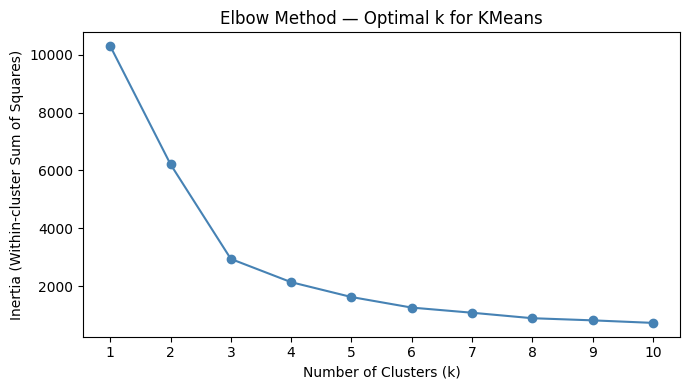


Based on the Elbow plot, k=3 is selected (elbow point where inertia starts to flatten).


In [33]:
print(" ELBOW METHOD (Finding Optimal k for KMeans)\n ")

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

# -------- Elbow Method --------
inertia_values = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertia_values, marker='o', color='steelblue')
plt.title("Elbow Method — Optimal k for KMeans")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-cluster Sum of Squares)")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

print("\nBased on the Elbow plot, k=3 is selected (elbow point where inertia starts to flatten).")


In [34]:
# KMEANS CLUSTERING
kmeans = KMeans(n_clusters=3,
                random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)
print("\nKMEANS RESULTS")
print("Silhouette Score:",
      round(silhouette_score(X_pca,
                             kmeans_labels), 4))
print("Davies Bouldin Score:",
      round(davies_bouldin_score(X_pca,
                                 kmeans_labels), 4))


KMEANS RESULTS
Silhouette Score: 0.552
Davies Bouldin Score: 0.6366


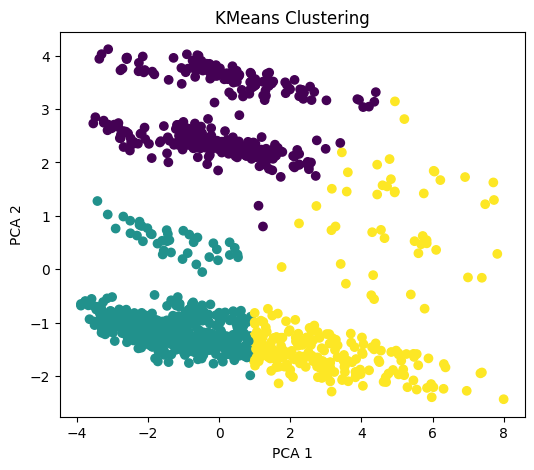

In [35]:
# KMeans Graph
plt.figure(figsize=(6, 5))

plt.scatter(X_pca[:, 0],
            X_pca[:, 1],
            c=kmeans_labels,
            cmap='viridis')

plt.title("KMeans Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [36]:
dbscan = DBSCAN(eps=0.5,
                min_samples=5)

dbscan_labels = dbscan.fit_predict(X_pca)

# Remove noise points
mask = dbscan_labels != -1

unique_clusters = set(dbscan_labels[mask])
if len(unique_clusters) > 1 and len(unique_clusters) < len(dbscan_labels[mask]):

    print("\nDBSCAN RESULTS")

    print("Silhouette Score:",
          round(silhouette_score(X_pca[mask],
                                 dbscan_labels[mask]), 4))

    print("Davies Bouldin Score:",
          round(davies_bouldin_score(X_pca[mask],
                                     dbscan_labels[mask]), 4))
else:
    print("\\nDBSCAN RESULTS")
    print("DBSCAN found only 1 cluster or all noise — cannot compute clustering scores.")



DBSCAN RESULTS
Silhouette Score: 0.1202
Davies Bouldin Score: 0.7727


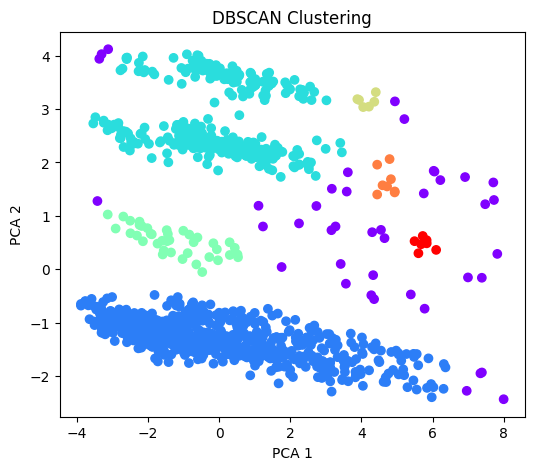

In [37]:
# DBSCAN Graph
plt.figure(figsize=(6, 5))

plt.scatter(X_pca[:, 0],
            X_pca[:, 1],
            c=dbscan_labels,
            cmap='rainbow')

plt.title("DBSCAN Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

In [38]:
print(" FEATURE SELECTION (Top 20 Features by ANOVA F-Score)")

selector = SelectKBest(score_func=f_classif, k=20)
selector.fit(X_train_original, y_train_original)

# Feature scores
scores = selector.scores_

# -------- Manually select Top 20 Features --------
TOP_N = k # Manually chosen — includes enough features to capture key patterns

# Get indices of top 20 features sorted by score (highest first)
top_indices = np.argsort(scores)[::-1][:TOP_N]

# Sort them back by column order so the array slicing stays consistent
selected_columns = sorted(top_indices.tolist())

# Apply to train and test
X_train = X_train_original[:, selected_columns]
X_test  = X_test_original[:, selected_columns]

# Print results
selected_feature_names = [original_feature_names[i] for i in selected_columns]
selected_scores        = [scores[i] for i in selected_columns]

print(f"\n Manually Selected Top {TOP_N} Features")
print(f" New Training Shape (before SMOTE): {X_train.shape}")
print(f" New Testing Shape: {X_test.shape}")

print("\nSelected Features (Highest to Lowest Score):")

for name, score in sorted(
    zip(selected_feature_names, selected_scores),
    key=lambda x: x[1],
    reverse=True
):
    print(name)

 FEATURE SELECTION (Top 20 Features by ANOVA F-Score)

 Manually Selected Top 10 Features
 New Training Shape (before SMOTE): (1176, 10)
 New Testing Shape: (294, 10)

Selected Features (Highest to Lowest Score):
OverTime_Yes
TotalWorkingYears
Age
MaritalStatus_Single
YearsWithCurrManager
YearsInCurrentRole
JobLevel
JobRole_Sales Representative
MonthlyIncome
YearsAtCompany


In [39]:
print(" IMBALANCE LEARNING ")

print("\nBefore Balancing:")
print(pd.Series(y_train).value_counts())

# Random Oversampling
ros = RandomOverSampler(random_state=42)

X_ros, y_ros = ros.fit_resample(X_train,
                                y_train)

print("\nAfter Random Oversampling:")
print(pd.Series(y_ros).value_counts())

# SMOTE
smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X_train,
                                      y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_smote).value_counts())

# Use SMOTE balanced data for training
X_train = X_smote
y_train = y_smote

 IMBALANCE LEARNING 

Before Balancing:
Attrition
0    986
1    190
Name: count, dtype: int64

After Random Oversampling:
Attrition
0    986
1    986
Name: count, dtype: int64

After SMOTE:
Attrition
0    986
1    986
Name: count, dtype: int64


In [40]:
models = {

    "Logistic Regression":
    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree":
    DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),

    "XGBoost":
    XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=5,
        eval_metric='logloss',
        random_state=42
    )
}


Logistic Regression
Accuracy : 69.7%
Precision: 31.2%
Recall   : 74.5%
F1 Score : 44.0%

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.69      0.79       247
           1       0.31      0.74      0.44        47

    accuracy                           0.70       294
   macro avg       0.62      0.72      0.62       294
weighted avg       0.83      0.70      0.74       294



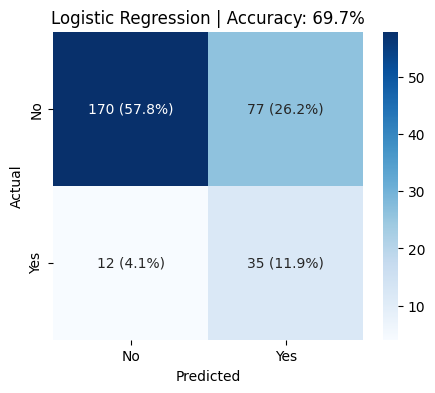


Decision Tree
Accuracy : 75.2%
Precision: 33.8%
Recall   : 57.4%
F1 Score : 42.5%

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.79      0.84       247
           1       0.34      0.57      0.43        47

    accuracy                           0.75       294
   macro avg       0.62      0.68      0.63       294
weighted avg       0.82      0.75      0.78       294



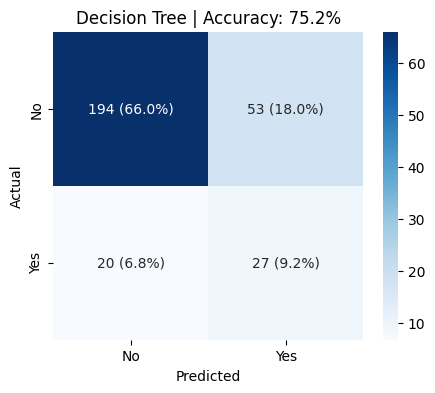


Random Forest
Accuracy : 79.3%
Precision: 37.0%
Recall   : 42.6%
F1 Score : 39.6%

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.86      0.87       247
           1       0.37      0.43      0.40        47

    accuracy                           0.79       294
   macro avg       0.63      0.64      0.64       294
weighted avg       0.80      0.79      0.80       294



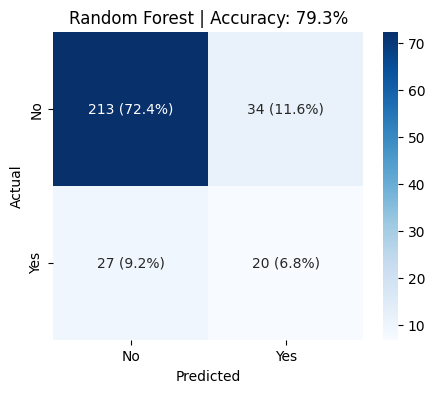


Gradient Boosting
Accuracy : 80.6%
Precision: 40.0%
Recall   : 42.6%
F1 Score : 41.2%

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.88      0.88       247
           1       0.40      0.43      0.41        47

    accuracy                           0.81       294
   macro avg       0.64      0.65      0.65       294
weighted avg       0.81      0.81      0.81       294



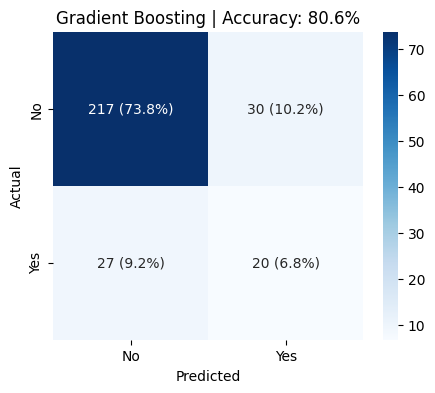


XGBoost
Accuracy : 73.8%
Precision: 31.2%
Recall   : 53.2%
F1 Score : 39.4%

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.78      0.83       247
           1       0.31      0.53      0.39        47

    accuracy                           0.74       294
   macro avg       0.60      0.65      0.61       294
weighted avg       0.80      0.74      0.76       294



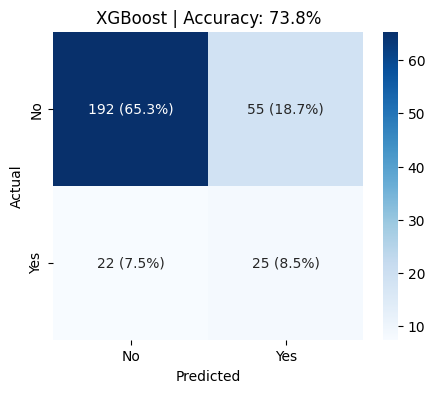

In [41]:
# --------------------------------
# Training & Evaluation
# --------------------------------

results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics (percentage format)
    acc = accuracy_score(y_test, y_pred) * 100
    pre = precision_score(y_test, y_pred, zero_division=0) * 100
    rec = recall_score(y_test, y_pred, zero_division=0) * 100
    f1  = f1_score(y_test, y_pred, zero_division=0) * 100

    results.append([name, acc, pre, rec, f1])

    print("\n==============================")
    print(name)
    print("==============================")

    print("Accuracy :", f"{acc:.1f}%")
    print("Precision:", f"{pre:.1f}%")
    print("Recall   :", f"{rec:.1f}%")
    print("F1 Score :", f"{f1:.1f}%")

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # --------------------------------
    # Confusion Matrix (Count + %)
    # --------------------------------

    cm = confusion_matrix(y_test, y_pred)

    cm_percent = cm / cm.sum() * 100

    labels = np.array([
        [f"{cm[0,0]} ({cm_percent[0,0]:.1f}%)",
         f"{cm[0,1]} ({cm_percent[0,1]:.1f}%)"],

        [f"{cm[1,0]} ({cm_percent[1,0]:.1f}%)",
         f"{cm[1,1]} ({cm_percent[1,1]:.1f}%)"]
    ])

    plt.figure(figsize=(5, 4))

    sns.heatmap(cm_percent,
                annot=labels,
                fmt="",
                cmap="Blues",
                xticklabels=["No", "Yes"],
                yticklabels=["No", "Yes"])

    plt.title(f"{name} | Accuracy: {acc:.1f}%")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()


========== FINAL RESULTS ==========
              Model  Accuracy  Precision    Recall  F1 Score
Logistic Regression 69.727891  31.250000 74.468085 44.025157
      Decision Tree 75.170068  33.750000 57.446809 42.519685
      Random Forest 79.251701  37.037037 42.553191 39.603960
  Gradient Boosting 80.612245  40.000000 42.553191 41.237113
            XGBoost 73.809524  31.250000 53.191489 39.370079

 BEST MODEL:

              Model  Accuracy  Precision    Recall  F1 Score
Logistic Regression 69.727891      31.25 74.468085 44.025157


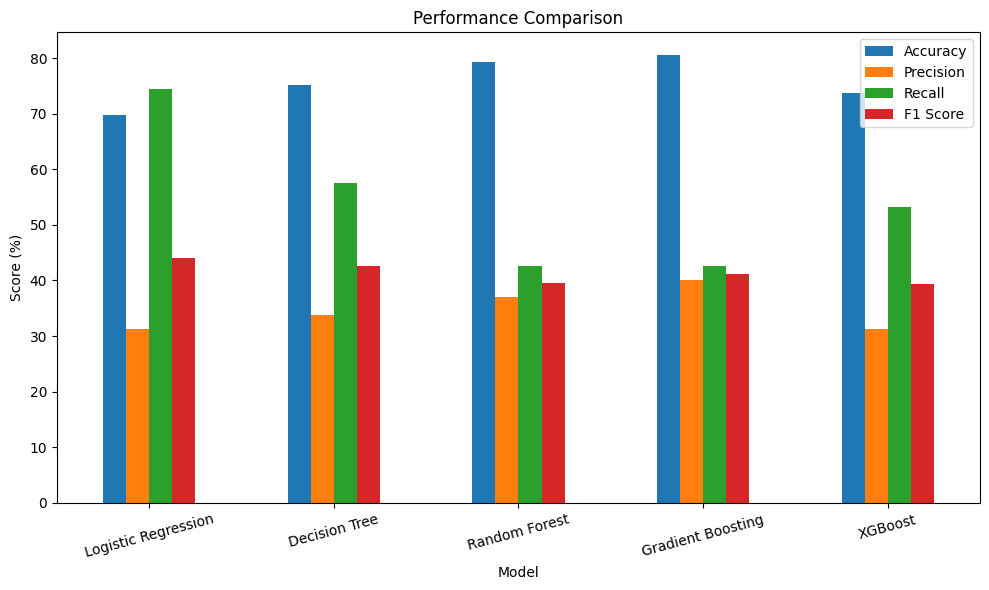

In [42]:
results_df = pd.DataFrame(results,
                          columns=['Model',
                                   'Accuracy',
                                   'Precision',
                                   'Recall',
                                   'F1 Score'])

print("\n========== FINAL RESULTS ==========")
print(results_df.to_string(index=False))

# Best Model
best_model = results_df.sort_values(by='F1 Score', ascending=False)

print("\n BEST MODEL:\n")
print(best_model.head(1).to_string(index=False))

results_df.plot(
    x='Model',
    y=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    kind='bar',
    figsize=(10, 6)
)

plt.title("Performance Comparison")
plt.ylabel("Score (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()